# Notebook para el análisis exploratorio de los datos EDA



Este notebook explora los datos antes de modelar: la distribución de la salud
financiera, qué ratios separan mejor a las empresas que se deterioran de las que se
mantienen sanas, las correlaciones entre ratios y las diferencias por sector. Aquí se
identifican los predictores clave y se entiende el desbalance de clases.

Entrada: `panel_enriquecido.csv` · Salidas: figuras en `outputs/`

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

panel = pd.read_csv("../data/processed/panel_enriquecido.csv")

# Filas modelables con la saluf
datos = panel.dropna(subset=["zona_futura"])
print("Filas para el análisis:", len(datos))

Filas para el análisis: 15877


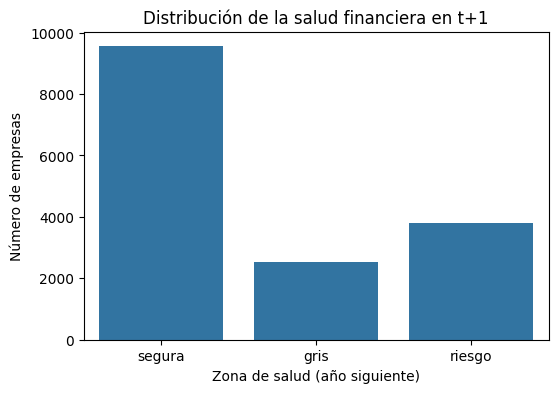

In [3]:
# Visualizar el objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=datos, x="zona_futura", order=["segura", "gris", "riesgo"])
plt.title("Distribución de la salud financiera en t+1")
plt.xlabel("Zona de salud (año siguiente)")
plt.ylabel("Número de empresas")
plt.savefig("../outputs/distribucion_objetivo.png", dpi=150, bbox_inches="tight")
plt.show()

Desbalance moderado hacia "segura"

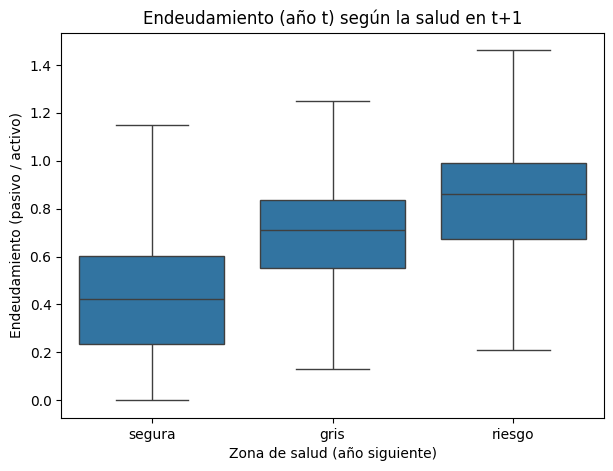

In [4]:
# Visualización de endeudamiento
plt.figure(figsize=(7, 5))
sns.boxplot(data=datos, x="zona_futura", y="endeudamiento",
            order=["segura", "gris", "riesgo"], showfliers=False)
plt.title("Endeudamiento (año t) según la salud en t+1")
plt.xlabel("Zona de salud (año siguiente)")
plt.ylabel("Endeudamiento (pasivo / activo)")
plt.show()

Los gráficos boxplot suben escalonadamente de izquierda a derecha, las empresas que terminan en "riesgo" tienen un endeudamiento mediano más alto ya en el año previo que las que se mantendrían "segureas". El apalancamiento parece ser un indicador potente y adelantado del deterioro.

Los ratios de hoy si contienen señal sobre la "salud" de mañana.

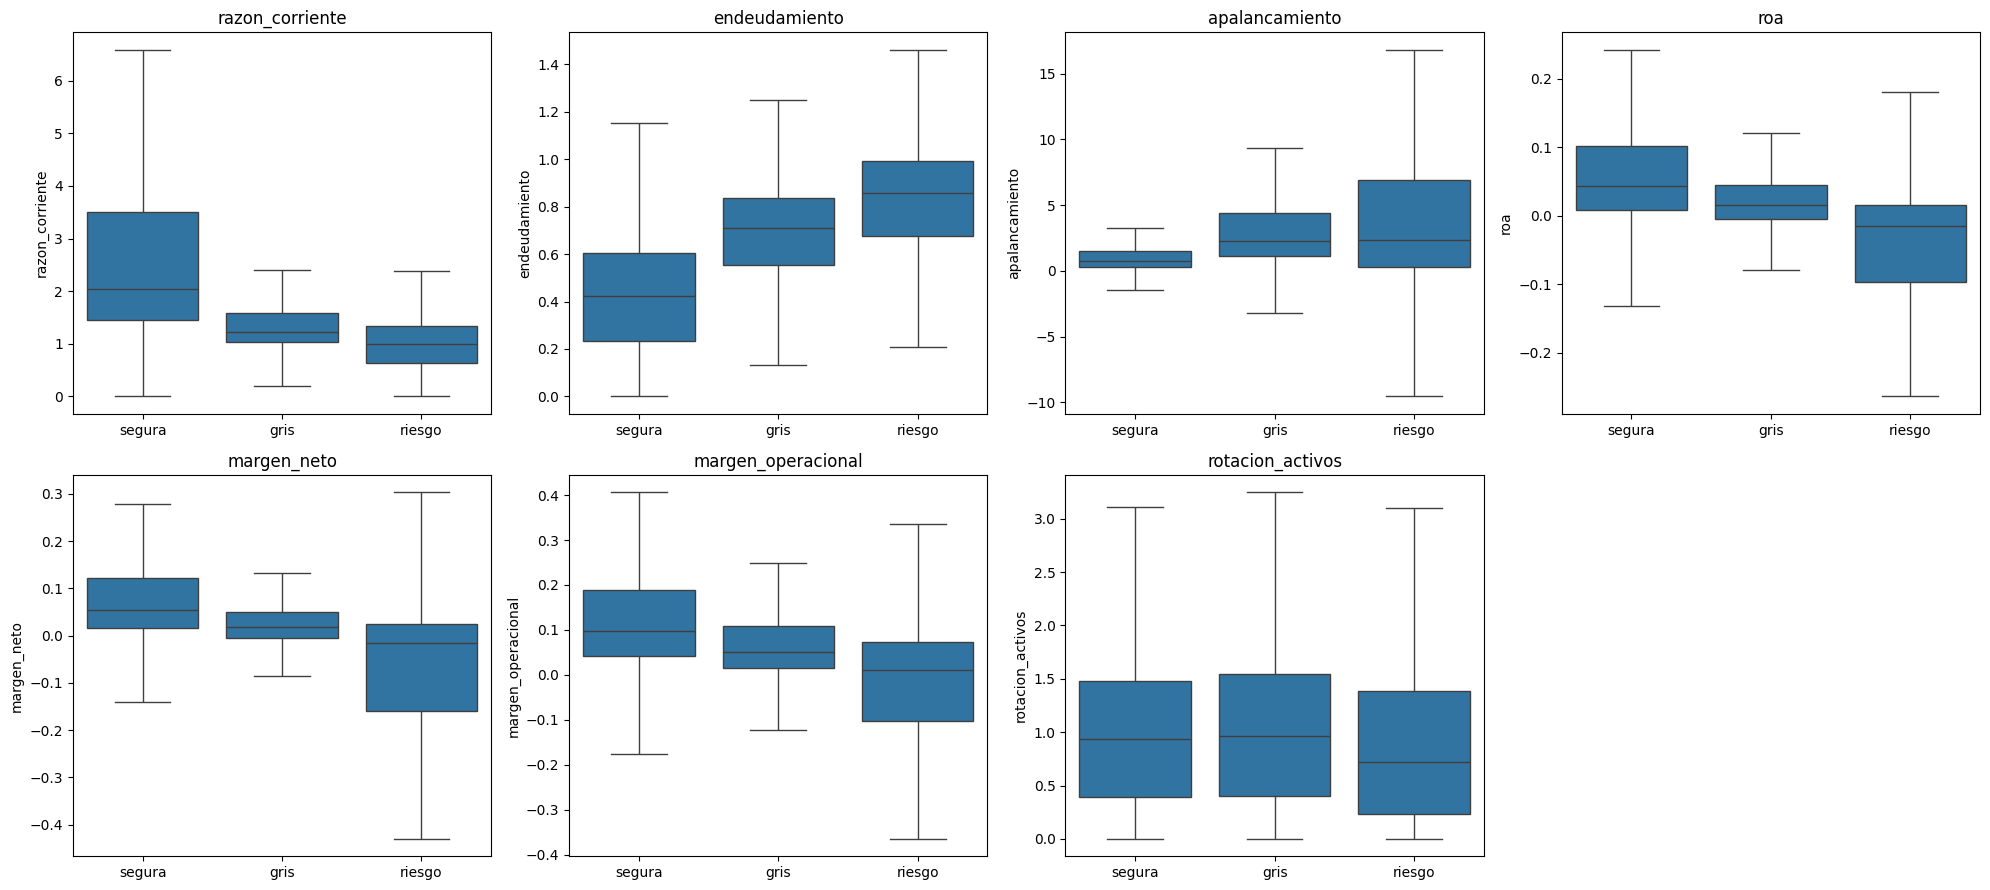

In [6]:
# todos los ratios{
ratios = ["razon_corriente", "endeudamiento", "apalancamiento", "roa",
          "margen_neto", "margen_operacional", "rotacion_activos"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, ratio in enumerate(ratios):
    sns.boxplot(data=datos, x="zona_futura", y=ratio,
                order=["segura", "gris", "riesgo"], showfliers=False, ax=axes[i])
    axes[i].set_title(ratio)
    axes[i].set_xlabel("")

axes[7].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/ratios_por_zona.png", dpi=150, bbox_inches="tight")
plt.show()

razon_corriente (liquidez): baja escalonadamente. Las empresas que se deteriorarán ya tienen menos liquidez. 

endeudamiento sube fuerte como se vio previamente.

apalancamiento: sube, pero la caja de "riesgo" es enorme y se mete en negativos, empresas con patrimonio negativo: ruidoso.

roa (rentabilidad): baja claramente. Las que caen en riesgo ya tienen rentabilidad pobre. 

margen_neto y margen_operacional: ambos bajan de forma limpia, con "riesgo" entrando en negativo.

rotacion_activos (eficiencia): No discrimina.



Las señales de alerta mas potentes parecen ser apalancamiento alto, liquidez baja y rentabilidad pobre.

La rotación de activos es esencialmente ventas/activos. Justamente el termino que elimina Altman para construir el Z´´ para mercados emergentes. Este dato acaba de confirmar empiricamente la decisión de Altman, el unico ratio que no discrimina el deterioro en la presente muestra es justo el que esta versión del modelo descarta.

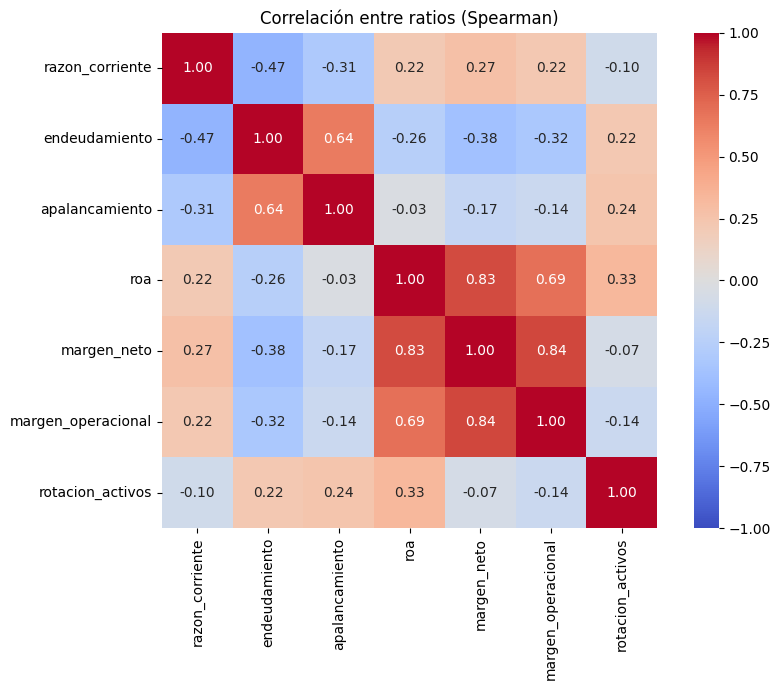

In [7]:
# Correlaciones
ratios = ["razon_corriente", "endeudamiento", "apalancamiento", "roa",
          "margen_neto", "margen_operacional", "rotacion_activos"]

# Correlación de Spearman
corr = datos[ratios].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True)
plt.title("Correlación entre ratios (Spearman)")
plt.tight_layout()
plt.savefig("../outputs/correlacion_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

Roa, margen neto y margen operacional estan altamente correlacionados entre si. Miden esencialmente lo mismo.

Endeudamiento y apalancaamiento tambien se correlacionan.

Lo demas es bastante independiente y la liquidez se relaciona negativamente con el endeudamiento.

En rentabilidad, roa es el mejor representante. Correlaciona 0.83 con el margen neto, así que captura casi la misma señal, pero no tiene datos faltantes (usa activos, no ingresos).
En apalancamiento, endeudamiento es mejor que apalancamiento, porque está acotado y no se dispara con el patrimonio negativo


Lo anterior da dos caminos para el modelo,  o reducir a un representante por dimensión, o conservarlos todos y controlar la redundancia con regularización.

zona_futura  segura   gris  riesgo
sector                            
R             0.204  0.056   0.741
P             0.269  0.346   0.385
B             0.566  0.095   0.339
I             0.498  0.168   0.333
F             0.477  0.198   0.325
S             0.537  0.146   0.317
J             0.570  0.138   0.292
D             0.519  0.212   0.269
M             0.631  0.130   0.238
H             0.640  0.124   0.237
G             0.584  0.183   0.233
A             0.623  0.159   0.218
N             0.624  0.162   0.214
C             0.641  0.156   0.203
L             0.654  0.144   0.203
Q             0.750  0.062   0.188
K             0.766  0.115   0.119
E             1.000  0.000   0.000


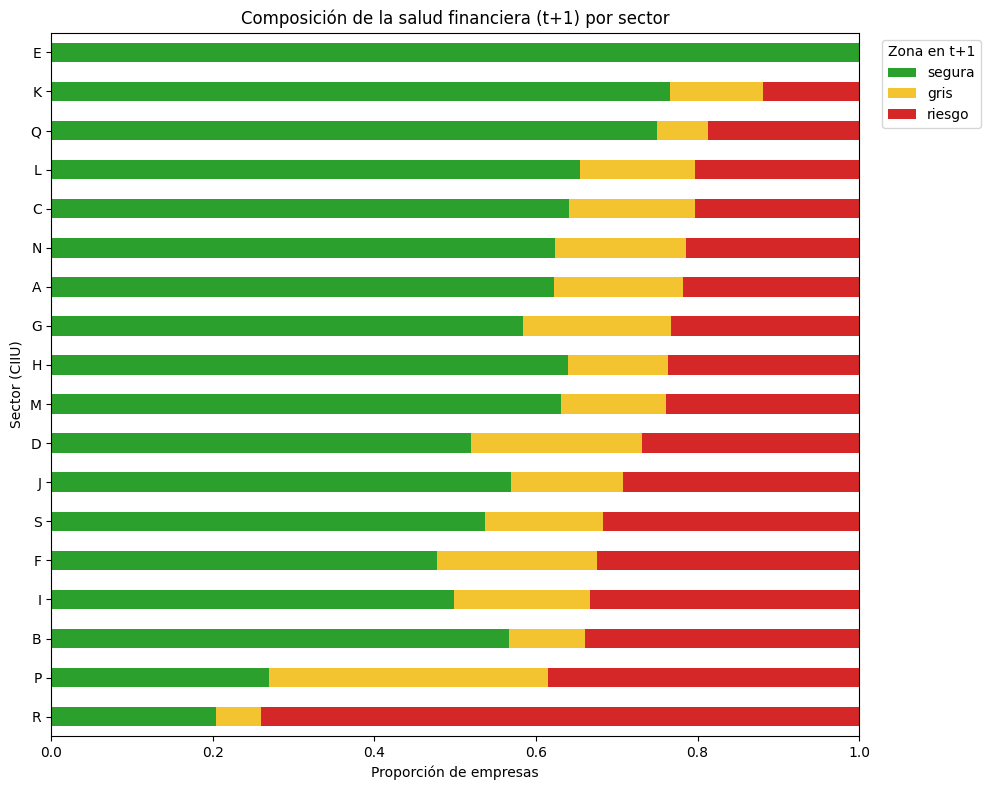

In [8]:
# analisis por sector
# se extrae el macrosector conprimera letra del código CIIU
datos["sector"] = datos["ciiu"].str[0]

# Proporción de cada zona por sector ordenada por riesgo
salud_sector = pd.crosstab(datos["sector"], datos["zona_futura"], normalize="index")
salud_sector = salud_sector[["segura", "gris", "riesgo"]].sort_values("riesgo", ascending=False)
print(salud_sector.round(3))


salud_sector.plot(kind="barh", stacked=True, figsize=(10, 8),
                  color=["#2ca02c", "#f4c430", "#d62728"])
plt.title("Composición de la salud financiera (t+1) por sector")
plt.xlabel("Proporción de empresas")
plt.ylabel("Sector (CIIU)")
plt.legend(title="Zona en t+1", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig("../outputs/salud_por_sector.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
datos["sector"].value_counts()

sector
G    4200
C    3608
F    1354
A    1249
L     864
J     848
M     843
B     814
N     790
K     556
H     283
I     273
R      54
D      52
S      41
P      26
Q      16
E       6
Name: count, dtype: int64

Gracias a esta ultima visualización y al value_counts() se observa que el gran riesgo de R se basa en 54 empresas y el 0 riesgo de E en apenas 6. 

Sectores grandes y confiables: G comercio (4.200), C manufactura (3.608), F construcción (1.354), A agro (1.249), L inmobiliario (864), J info (848), M profesionales (843), B minería (814), N admin (790), K financiero (556), H transporte (283), I turismo (273).

Dejando de lado los extremos ruidosos los sectores mas riegosos son construcción (F), turismo/alojamiento (I) y minería (B). Son sectores cíclicos e intensivos en capital.
Los mas seguros: financiero (K) y salud (Q), sectores más estables o más regulados.

Existe variación sectorial moderada, con los sectores cíclicos (construcción, turismo, minería) mostrando mayor propensión al deterioro, pero los extremos corresponden a sectores con muestras pequeñas.
